# Glove CSV loader
This notebook loads the attached glove CSV, displays the dataset, and plots a few example signals.


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

csv_path = Path('glove_data_right_rock_33_2026-04-17_13-54-50.csv')
df = pd.read_csv(csv_path)
print(f'Loaded: {csv_path}')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()


Loaded: glove_data_right_rock_33_2026-04-17_13-54-50.csv
Shape: 27 rows x 94 columns


,run_index,hand,glove_time_ms,time,palm_mcp_flex,palm_pip_flex,palm_mid_yaw,palm_mid_pitch,palm_mid_roll,palm_mid_ax,...,pinky_prox_roll,pinky_prox_ax,pinky_prox_ay,pinky_prox_az,wrist_ax,wrist_ay,wrist_az,wrist_heading,wrist_pitch,wrist_roll
0,33,RightGlove,989757,0,-1,-1,0,0,0,0,...,0.18,0.0,-0.01,-0.13,-2.91,-0.26,9.39,186.88,-17.44,1.69
1,33,RightGlove,990435,389,-1,-1,0,0,0,0,...,0.00,0.0,0.00,0.00,-2.97,-0.28,9.38,186.88,-17.50,1.69
2,33,RightGlove,990481,497,-1,-1,0,0,0,0,...,0.18,0.0,0.01,-0.12,-2.97,-0.29,9.32,186.88,-17.50,1.69
3,33,RightGlove,990590,672,-1,-1,0,0,0,0,...,0.18,0.0,0.00,-0.11,-2.94,-0.28,9.38,186.88,-17.44,1.69
4,33,RightGlove,990765,912,-1,-1,0,0,0,0,...,0.18,0.0,0.00,-0.12,-2.93,-0.30,9.56,186.94,-17.31,1.69


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 94 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   run_index          27 non-null     int64  
 1   hand               27 non-null     str    
 2   glove_time_ms      27 non-null     int64  
 3   time               27 non-null     int64  
 4   palm_mcp_flex      27 non-null     int64  
 5   palm_pip_flex      27 non-null     int64  
 6   palm_mid_yaw       27 non-null     int64  
 7   palm_mid_pitch     27 non-null     int64  
 8   palm_mid_roll      27 non-null     int64  
 9   palm_mid_ax        27 non-null     int64  
 10  palm_mid_ay        27 non-null     int64  
 11  palm_mid_az        27 non-null     int64  
 12  palm_prox_yaw      27 non-null     float64
 13  palm_prox_pitch    27 non-null     float64
 14  palm_prox_roll     27 non-null     float64
 15  palm_prox_ax       27 non-null     float64
 16  palm_prox_ay       27 non-null     floa

In [4]:
display(df.describe(include='all').T.head(20))


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
run_index,27.0,NaN,NaN,NaN,33.0,0.0,33.0,33.0,33.0,33.0,33.0
hand,27,1,RightGlove,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
glove_time_ms,27.0,NaN,NaN,NaN,993843.296296,2629.886848,989757.0,991481.5,993752.0,996032.0,998229.0
time,27.0,NaN,NaN,NaN,4059.0,2664.470246,0.0,1737.0,4007.0,6273.5,8474.0
palm_mcp_flex,27.0,NaN,NaN,NaN,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0
palm_pip_flex,27.0,NaN,NaN,NaN,-1.0,0.0,-1.0,-1.0,-1.0,-1.0,-1.0
palm_mid_yaw,27.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
palm_mid_pitch,27.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
palm_mid_roll,27.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
palm_mid_ax,27.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


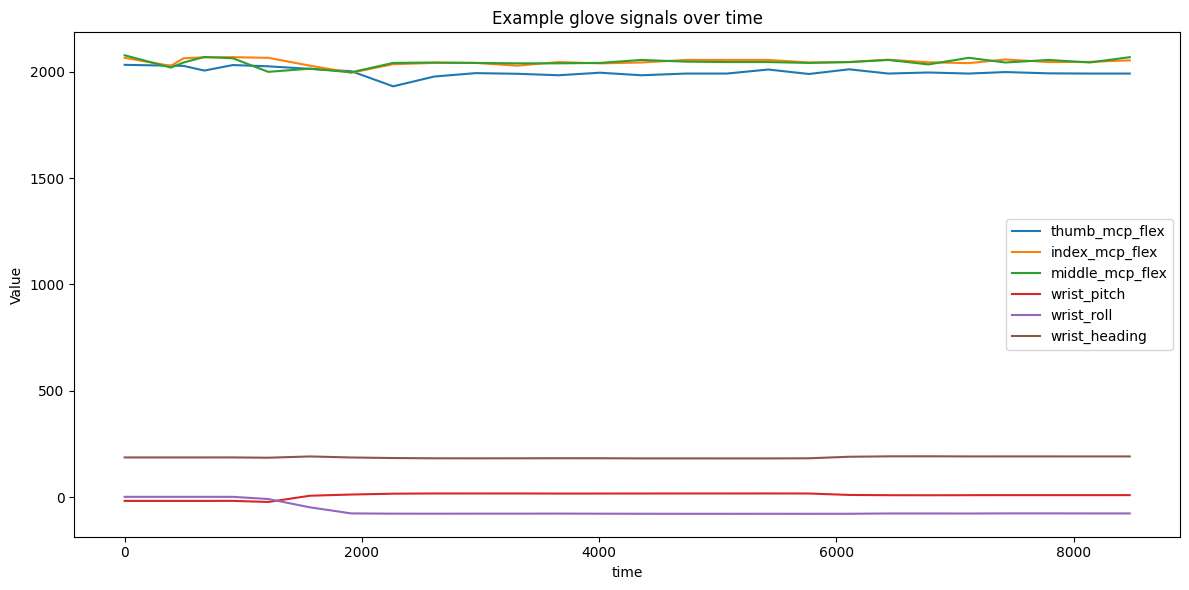

In [5]:
time_col = 'time' if 'time' in df.columns else df.columns[0]
example_cols = [c for c in ['thumb_mcp_flex', 'index_mcp_flex', 'middle_mcp_flex', 'wrist_pitch', 'wrist_roll', 'wrist_heading'] if c in df.columns]

ax = df.plot(x=time_col, y=example_cols, figsize=(12, 6), title='Example glove signals over time')
ax.set_xlabel(time_col)
ax.set_ylabel('Value')
plt.tight_layout()
plt.show()


In [6]:
zero_heavy_cols = []
for col in df.select_dtypes(include='number').columns:
    if len(df[col]) and (df[col] == 0).mean() > 0.5:
        zero_heavy_cols.append(col)

print('Numeric columns with >50% zeros:')
print(zero_heavy_cols[:50])


Numeric columns with >50% zeros:
['palm_mid_yaw', 'palm_mid_pitch', 'palm_mid_roll', 'palm_mid_ax', 'palm_mid_ay', 'palm_mid_az']
